# Proyek Analisis Data: [PRSA_Data_Dingling_20130301-20170228]
- **Nama:** [Gamael Marcel]
- **Email:** [gamaelmarcel@gmail.com]
- **ID Dicoding:** [stelleguy]

## Menentukan Pertanyaan Bisnis

- Bagaimana tren kadar PM2.5 pada tahun 2016 di Stasiun Dingling?
- Bagaimana tren kadar PM10 pada tahun 2016 di Stasiun Dingling?
- Bagaimana tren kualitas udara mencakup suhu dan tekanan angin pada tahun 2016 di Stasiun Dingling?
- Bagaimana kualitas udara seperti titik embun, curah hujan, dan kecepatan angin pada tahun 2016 di Stasiun Dingling?
- Bagaimana distribusi arah mata angin pada tahun 2016 di Stasiun Dingling?
- Bagaimana status kualitas udara pada tahun 2016 di Stasiun Dingling berdasarkan PM2.5 dan PM10 di setiap bulannya?
- Bagaimana hubungan antara suhu dengan tekanan angin pada tahun 2016 di Stasisun Dingling?

## Import Semua Packages/Library yang Digunakan

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import chi2_contingency

## Data Wrangling

### Gathering Data

Penjelasan tahapan:
- Dilakukan pengambilan raw database dari github untuk analisis cuaca di stasiun Dingling, China.

In [3]:
ding_df = pd.read_csv("https://raw.githubusercontent.com/marceloreis/HTI/refs/heads/master/PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv")
ding_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling


**Insight:**
- Pengukuran kualitas udara, paramaeter suhu, dan tekanan udara dilakukan setiap satu jam dimulai dari tanggal 1 Maret 2013.
- Terdapat beberapa variabel polutan udara untuk mengukur kualitas udara yang juga dipakai oleh BMKG seperti PM2.5, PM10, SO2, NO2, CO, dan O3, yang paling sering digunakan adalah PM2.5 dan PM10 yang mengancam kesehatan saluran pernapasan.
- Terdapat beberapa variabel untuk mengukur kualitas udara seperti yaitu suhu, tekanan angin, titik embun, curah hujan, arah angin, dan kecepatan angin.

### Assessing Data

Penjelasan tahapan:
- Dilakukan look up terhadap parameter-parameter di database beserta sebaran, distribusi, dan central tendencynya.

In [4]:
ding_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34285 non-null  float64
 6   PM10     34408 non-null  float64
 7   SO2      34334 non-null  float64
 8   NO2      33830 non-null  float64
 9   CO       33052 non-null  float64
 10  O3       33850 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [5]:
print("Duplicates: ", ding_df.duplicated().sum())
ding_df.describe(include="all")

Duplicates:  0


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34285.000000,34408.000000,34334.000000,33830.000000,33052.000000,33850.000000,35011.000000,35014.000000,35011.000000,35013.000000,34924,35021.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NNW,NaN,Dingling
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4776,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,65.989497,83.739723,11.749650,27.585467,904.896073,68.548371,13.686111,1007.760278,1.505495,0.060366,NaN,1.853836,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,72.267723,79.541685,15.519259,26.383882,903.306220,53.764424,11.365313,10.225664,13.822099,0.752899,NaN,1.309808,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,14.000000,26.000000,2.000000,9.000000,300.000000,31.000000,3.400000,999.300000,-10.200000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,41.000000,60.000000,5.000000,19.000000,600.000000,61.000000,14.700000,1007.400000,1.800000,0.000000,NaN,1.500000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,93.000000,117.000000,15.000000,38.000000,1200.000000,90.000000,23.300000,1016.000000,14.200000,0.000000,NaN,2.300000,NaN


**Insight:**
- Dataset ini mencakup kualitas udara, paramaeter suhu, dan tekanan udara di stasiun Dingling sejak tahun 2013 hingga tahun 2017.
- Terdapat data numerik yaitu PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, dan WSPM, sementara data kategorik yaitu wd (wind direction).

### Cleaning Data

Penjelasan tahapan:
- Dilakukan drop kolom stasiun untuk mencegah redundancy.


In [6]:
ding_df = ding_df.drop(columns = ["station"])
ding_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1


Penjelasan tahapan:
- Dilakukan pemeriksaan untuk melihat apakah ada data null/empty di parameter tersebut.

In [7]:
ding_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,779
PM10,656
SO2,730
NO2,1234
CO,2012


Penjelasan tahapan:
- Dilakukan forward filling untuk menambatkan data null dari nilai sebelumnya.

In [8]:
ding_df = ding_df.ffill()

Penjelasan tahapan:
- Dilakukan pemeriksaan kembali untuk melihat apakah ada data null/empty di parameter tersebut.

In [9]:
ding_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,2
CO,0


**Insight:**
- Terdapat beberapa data null di parameter kualitas udara baik data numerik dan data kategoriknya.
- Setelah dilakukan forward fill (pengisian data yang hilang ke depan), sudah tidak ada data nullnya.

## Exploratory Data Analysis (EDA)

### Explore dataframe generally

Penjelasan tahapan:
- Dilakukan pemeriksaan nilai di tiap parameter dengan mengambil 5 sampel.

In [10]:
ding_df.sample(5)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
12425,12426,2014,7,31,17,216.0,216.0,2.0,25.0,1700.0,293.0,30.6,995.4,21.1,0.0,SSE,2.1
804,805,2013,4,3,12,153.0,153.0,38.0,63.0,1300.0,67.0,20.0,1002.3,-1.8,0.0,SSE,2.5
18833,18834,2015,4,24,17,61.0,166.0,6.0,17.0,400.0,160.0,26.6,1006.7,-2.2,0.0,SSE,3.3
28851,28852,2016,6,15,3,5.0,5.0,2.0,9.0,300.0,43.0,16.9,993.2,14.4,0.0,NNW,0.6
11924,11925,2014,7,10,20,23.0,56.0,2.0,15.0,400.0,148.0,30.3,989.5,15.2,0.0,N,1.7


Penjelasan tahapan:
- Dilakukan perhitungan jumlah sampel di setiap tahunnya.

In [11]:
ding_df.groupby(by='year').No.count()

,No
year,
2013,7344
2014,8760
2015,8760
2016,8784
2017,1416


Penjelasan tahapan:
- Dilakukan pengurutan dari yang terbesar ke terkecil untuk jumlah sampel di setiap tahunnya.

In [12]:
ding_df.year.value_counts().sort_values(ascending=False)

,count
year,
2016,8784
2015,8760
2014,8760
2013,7344
2017,1416


Penjelasan tahapan:
- Dilakukan perhitungan jumlah nilai unik di setiap paramternya.

In [13]:
ding_df.nunique()

,0
No,35064
year,5
month,12
day,31
hour,24
PM2.5,486
PM10,554
SO2,327
NO2,636
CO,103


### Set Dataframe

Penjelasan tahapan:
- Dibuat array months dalam bentuk string setiap bulannya.
- Dilakukan filtering sehingga, dataframe yang digunakan adalah hanya pada tahun 2016.

In [14]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

In [15]:
ding_2016_df = ding_df[ding_df["year"] == 2016]

In [16]:
ding_2016_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
24864,24865,2016,1,1,0,90.0,90.0,22.0,76.0,3600.0,2.0,-3.8,1019.6,-9.6,0.0,NNW,1.2
24865,24866,2016,1,1,1,82.0,82.0,20.0,79.0,3500.0,2.0,-3.8,1018.8,-9.8,0.0,N,1.5
24866,24867,2016,1,1,2,89.0,89.0,21.0,80.0,3400.0,2.0,-3.9,1018.6,-9.7,0.0,N,1.1
24867,24868,2016,1,1,3,84.0,84.0,20.0,80.0,3300.0,2.0,-3.7,1018.0,-9.7,0.0,NNW,1.3
24868,24869,2016,1,1,4,89.0,89.0,20.0,81.0,3200.0,2.0,-4.9,1017.3,-9.9,0.0,NW,1.1


### EDA Univariate Numerikal

Penjelasan tahapan:
- Dilakukan grouping/merging menjadi variabel air_pol dari database untuk parameter PM2.5, lalu dihitung reratanya setiap bulan, dan mengambil tahun 2016 dan dipisahkan setiap bulannya.
- Dilakukan visualisasi rerata PM2.5 setiap bulan pada tahun 2016 dengan barplot.
- Dilakukan visualisasi sebaran PM2.5 setiap bulan pada tahun 2016 dengan boxplot.

In [17]:
air_pol = ding_df.groupby(by = ['year', 'month']).agg({
    "PM2.5" : "mean",
    "PM10" : "mean",
}).sort_values(by= ['year', 'month'], ascending = True)
air_pol = air_pol.reset_index()
air_pol = air_pol[(air_pol.year == 2016)]
air_pol

,year,month,PM2.5,PM10
34,2016,1,53.833333,72.701613
35,2016,2,35.554598,50.981322
36,2016,3,82.810484,131.787634
37,2016,4,60.886111,117.018056
38,2016,5,54.673387,85.774194
39,2016,6,49.056944,63.779167
40,2016,7,57.411290,62.083333
41,2016,8,37.262097,44.619624
42,2016,9,41.779167,49.331944
43,2016,10,111.706989,83.571237


Penjelasan tahapan:
- Dilakukan perhitungan rata-rata variabel PM2.5 dan PM10 dari variabel air_pol.

In [18]:
air_pol.mean()

,0
year,2016.000000
month,6.500000
PM2.5,62.938148
PM10,80.558561


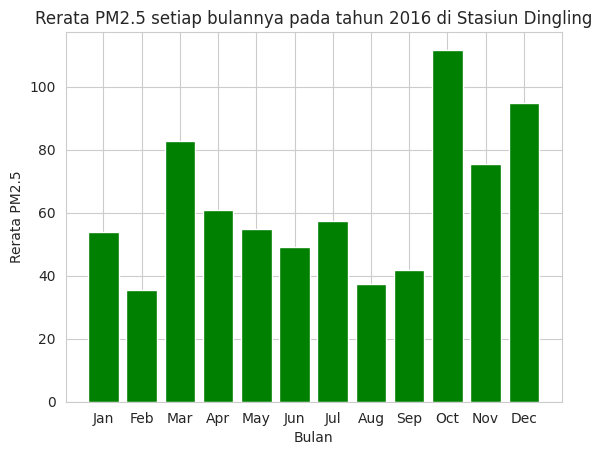

In [19]:
sns.set_style("whitegrid")
plt.bar(height=air_pol["PM2.5"], x=months, color='green')
plt.xlabel("Bulan")
plt.ylabel("Rerata PM2.5")
plt.title("Rerata PM2.5 setiap bulannya pada tahun 2016 di Stasiun Dingling")
plt.show()

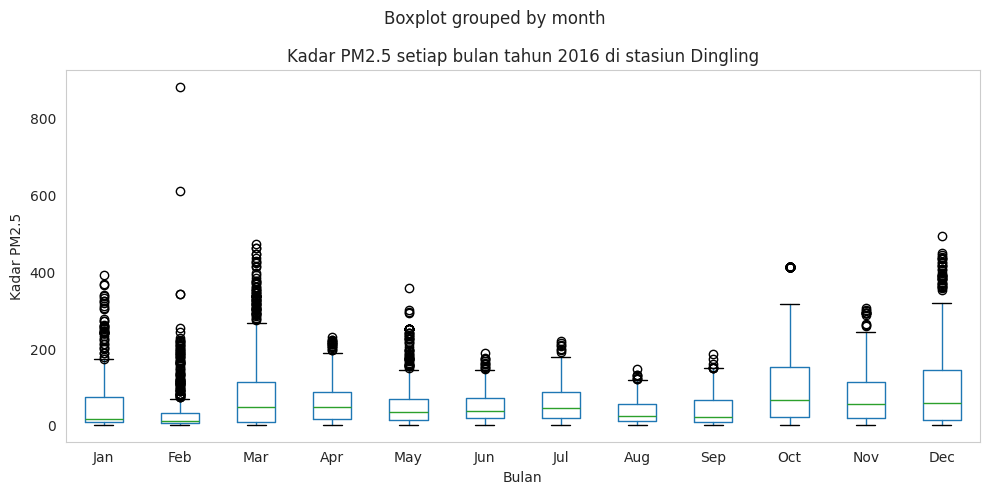

In [20]:
ding_2016_df.boxplot(by="month", column="PM2.5", grid=False, figsize=(10,5))
plt.title("Kadar PM2.5 setiap bulan tahun 2016 di stasiun Dingling")
plt.xlabel("Bulan")
plt.xticks(range(1,13), months)
plt.ylabel("Kadar PM2.5")
plt.tight_layout()
plt.show()

Penjelasan:
- Dilakukan listing dilanjutkan dengan visualisasi distribusi terhadap data outliers untuk PM2.5 beserta bulannya menggunakan scatterplot.

In [21]:
def outliers(df, column):
  q1 = df[column].quantile(0.25)
  q3 = df[column].quantile(0.75)
  iqr = q3 - q1
  lower = q1 - (1.5 * iqr)
  upper = q3 + (1.5 * iqr)
  return df[(df[column] < lower) | (df[column] > upper)]

df_1 = outliers(ding_2016_df, 'PM2.5')
df_1_month = df_1.groupby('month')['PM2.5'].apply(sorted).reset_index()
df_1_month.columns = ['month', 'PM2.5']
print(df_1_month)

   month                                              PM2.5
0      1  [200.0, 202.0, 206.0, 212.0, 214.0, 220.0, 226...
1      2  [196.0, 199.0, 201.0, 203.0, 207.0, 209.0, 210...
2      3  [202.0, 205.0, 208.0, 215.0, 219.0, 220.0, 222...
3      4  [198.0, 198.0, 203.0, 205.0, 208.0, 208.0, 212...
4      5  [197.0, 198.0, 198.0, 205.0, 213.0, 218.0, 218...
5      7         [197.0, 200.0, 207.0, 211.0, 215.0, 221.0]
6     10  [197.0, 200.0, 201.0, 204.0, 205.0, 208.0, 209...
7     11  [196.0, 197.0, 199.0, 200.0, 202.0, 202.0, 204...
8     12  [196.0, 196.0, 197.0, 198.0, 199.0, 199.0, 199...


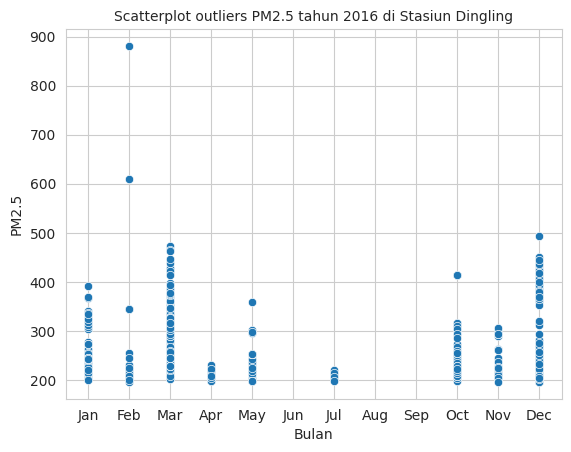

In [22]:
sns.scatterplot(x="month", y='PM2.5', data=df_1)
plt.xlabel("Bulan")
plt.xticks(range(1,13), months)
plt.title("Scatterplot outliers PM2.5 tahun 2016 di Stasiun Dingling", fontsize=10)
plt.show()

Penjelasan tahapan:
- Dilakukan grouping/merging menjadi variabel air_pol dari database untuk parameter PM10, lalu dihitung reratanya setiap bulan, dan mengambil tahun 2016 dan dipisahkan setiap bulannya.
- Dilakukan visualisasi rerata PM10 setiap bulan pada tahun 2016 dengan barplot.
- Dilakukan visualisasi sebaran PM10 setiap bulan pada tahun 2016 dengan boxplot.

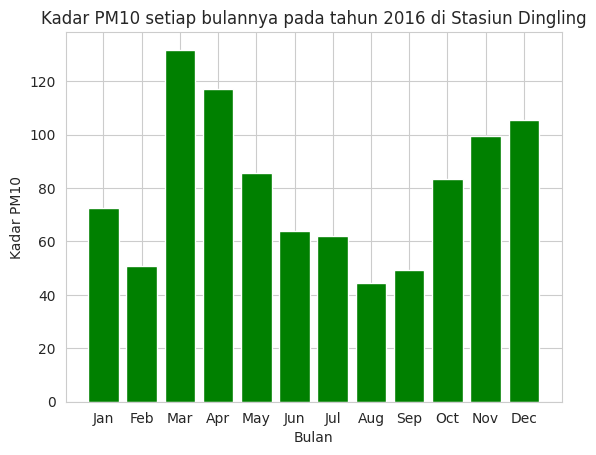

In [23]:
plt.bar(height=air_pol["PM10"], x=months, color='green')
plt.xlabel("Bulan")
plt.ylabel("Kadar PM10")
plt.title("Kadar PM10 setiap bulannya pada tahun 2016 di Stasiun Dingling")
plt.show()

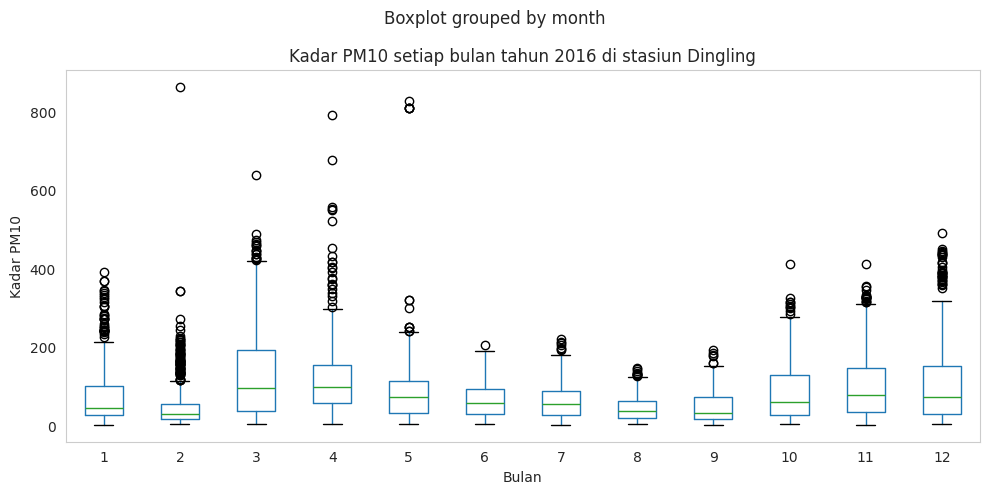

In [24]:
ding_2016_df.boxplot(by="month", column="PM10", grid=False, figsize=(10,5))
plt.title("Kadar PM10 setiap bulan tahun 2016 di stasiun Dingling")
plt.xlabel("Bulan")
plt.ylabel("Kadar PM10")
plt.tight_layout()
plt.show()

Penjelasan:
- Dilakukan listing dilanjutkan dengan visualisasi distribusi terhadap data outliers untuk PM10 beserta bulannya menggunakan scatterplot.

In [25]:
df_2 = outliers(ding_2016_df, 'PM10')
df_2_month = df_2.groupby('month')['PM10'].apply(sorted).reset_index()
df_2_month.columns = ['month', 'PM10']
print(df_2_month)

   month                                               PM10
0      1  [241.0, 242.0, 243.0, 243.0, 243.0, 244.0, 245...
1      2         [245.0, 255.0, 272.0, 344.0, 344.0, 864.0]
2      3  [238.0, 238.0, 238.0, 240.0, 240.0, 240.0, 241...
3      4  [238.0, 240.0, 241.0, 243.0, 243.0, 245.0, 252...
4      5  [239.0, 243.0, 243.0, 253.0, 253.0, 253.0, 302...
5     10  [238.0, 243.0, 245.0, 250.0, 250.0, 251.0, 253...
6     11  [245.0, 246.0, 248.0, 252.0, 263.0, 264.0, 266...
7     12  [238.0, 239.0, 241.0, 241.0, 242.0, 246.0, 246...


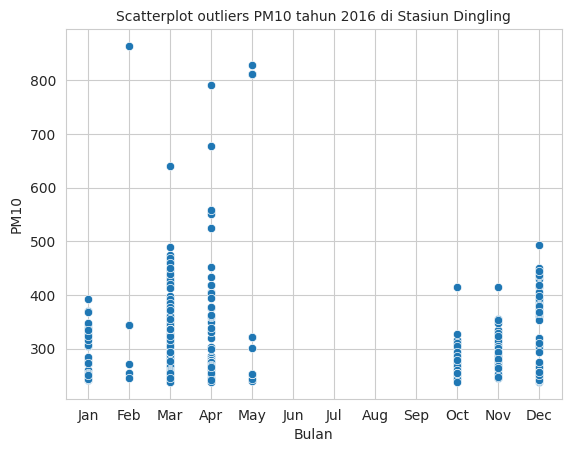

In [26]:
sns.scatterplot(x="month", y='PM10', data=df_2)
plt.xlabel("Bulan")
plt.xticks(range(1,13), months)
plt.title("Scatterplot outliers PM10 tahun 2016 di Stasiun Dingling", fontsize=10)
plt.show()

Penjelasan tahapan:
- Dilakukan grouping/merging menjadi variabel air_par dari database untuk parameter TEMP atau suhu (dalam 'C), lalu dihitung reratanya setiap bulan, dan mengambil tahun 2016 dan dipisahkan setiap bulannya.
- Dilakukan visualisasi dengan barplot dan boxplot untuk melihat secara jelas dan dapat dibandingkan per bulannya.
- Dilakukan juga plotting dengan QQ plot untuk melihat distribusi normal grafiknya.

In [27]:
air_par = ding_df.groupby(by = ['year', 'month']).agg({
    "TEMP" : "mean",
    "PRES" : "mean",
}).sort_values(by= ['year', 'month'], ascending = True)
air_par = air_par.reset_index()
air_par = air_par[(air_par.year == 2016)]
air_par

,year,month,TEMP,PRES
34,2016,1,-4.150269,1020.831586
35,2016,2,1.436494,1017.491810
36,2016,3,8.850134,1011.735484
37,2016,4,16.328056,1002.881111
38,2016,5,21.062903,1000.704167
39,2016,6,25.385694,996.016528
40,2016,7,27.111290,995.996909
41,2016,8,27.188441,998.986694
42,2016,9,21.401727,1004.590972
43,2016,10,12.818898,1012.188777


Penjelasan tahapan:
- Dilakukan perhitungan rata-rata variabel TEMP dan PRES dari variabel air_par.

In [28]:
air_par.mean()

,0
year,2016.000000
month,6.500000
TEMP,13.470883
PRES,1007.935966


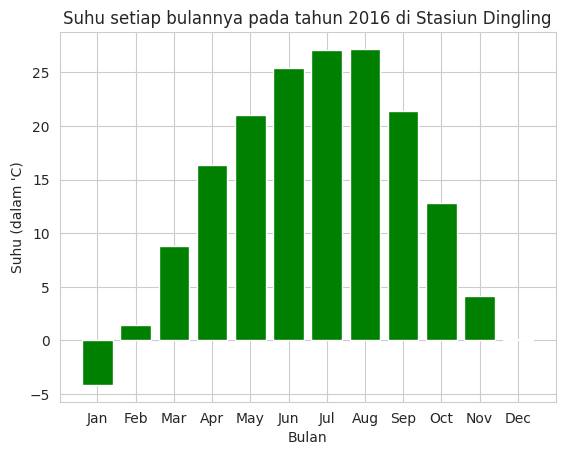

In [29]:
plt.bar(height=air_par["TEMP"], x=months, color='green')
plt.xlabel("Bulan")
plt.ylabel("Suhu (dalam 'C)")
plt.title("Suhu setiap bulannya pada tahun 2016 di Stasiun Dingling")
plt.show()

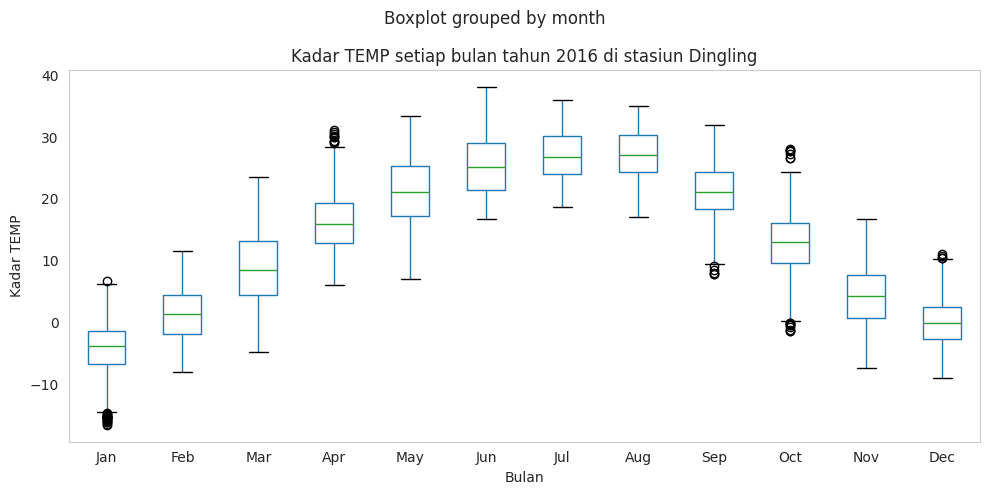

In [30]:
ding_2016_df.boxplot(by="month", column="TEMP", grid=False, figsize=(10,5))
plt.title("Kadar TEMP setiap bulan tahun 2016 di stasiun Dingling")
plt.xlabel("Bulan")
plt.xticks(range(1,13), months)
plt.ylabel("Kadar TEMP")
plt.tight_layout()
plt.show()

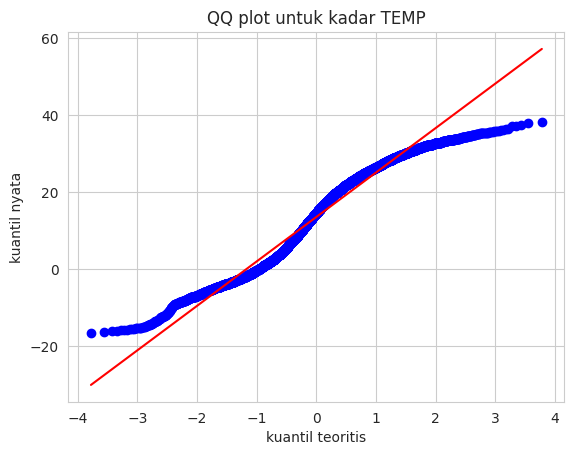

In [31]:
stats.probplot(ding_2016_df['TEMP'], plot=plt)
plt.title("QQ plot untuk kadar TEMP")
plt.xlabel("kuantil teoritis")
plt.ylabel("kuantil nyata")
plt.grid(True)
plt.show()

Insight:
- Bulan Januari dan Desember memperlihatkan grafik yang berada sama dengan dan di bawah 0'C, menandakan saat itu terjadi musim dingin.
- Terdapat beberapa outlier di bulan Januari, April, September, Oktober, dan Desember.
- QQ plot menunjukkan sebaran data tidak normal karena ujung kiri dan kanan keluar dari garis linier.

Penjelasan tahapan:
- Dilakukan grouping/merging menjadi variabel air_par dari database untuk parameter PRES atau tekanan angin (dalam hPa), lalu dihitung reratanya setiap bulan, dan mengambil tahun 2016 dan dipisahkan setiap bulannya.
- Dilakukan visualisasi dengan barplot dan boxplot untuk melihat secara jelas dan dapat dibandingkan per bulannya.
- Dilakukan juga plotting dengan QQ plot untuk melihat distribusi normal grafiknya.

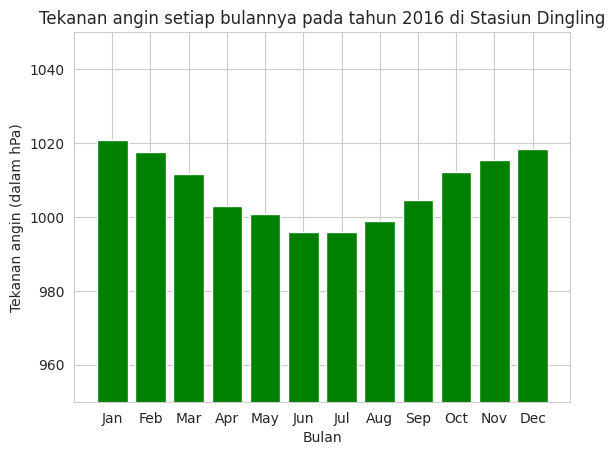

In [32]:
plt.bar(height=air_par["PRES"], x=months, color='green')
plt.ylim(950,1050)
plt.xlabel("Bulan")
plt.ylabel("Tekanan angin (dalam hPa)")
plt.title("Tekanan angin setiap bulannya pada tahun 2016 di Stasiun Dingling")
plt.show()

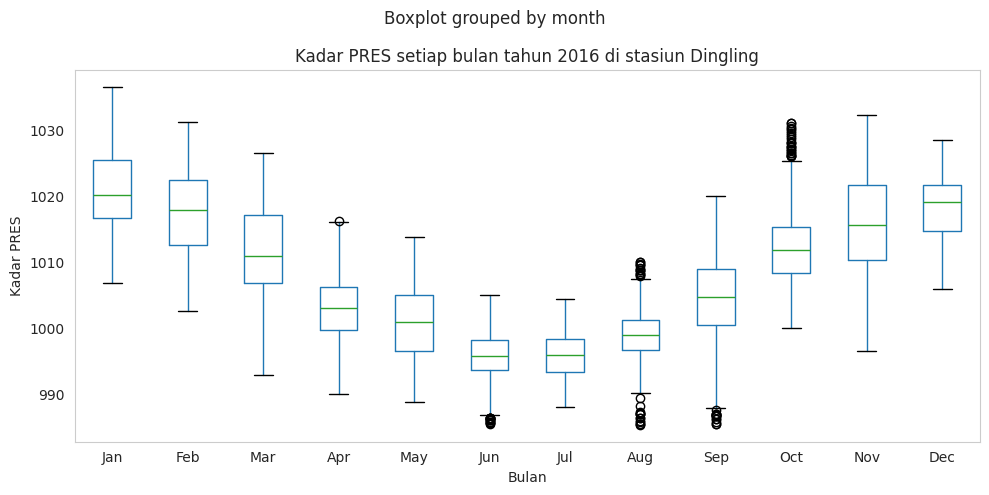

In [33]:
ding_2016_df.boxplot(by="month", column="PRES", grid=False, figsize=(10,5))
plt.title("Kadar PRES setiap bulan tahun 2016 di stasiun Dingling")
plt.xlabel("Bulan")
plt.xticks(range(1,13), months)
plt.ylabel("Kadar PRES")
plt.tight_layout()
plt.show()

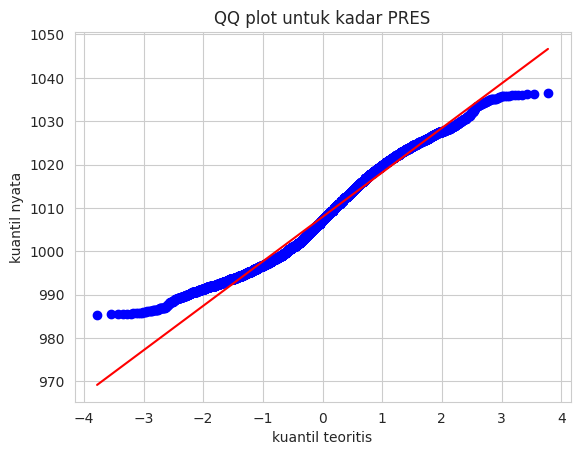

In [34]:
stats.probplot(ding_2016_df['PRES'], plot=plt)
plt.title("QQ plot untuk kadar PRES")
plt.xlabel("kuantil teoritis")
plt.ylabel("kuantil nyata")
plt.grid(True)
plt.show()

Insight:
- Bulan Juni dan Juli memperlihatkan grafik yang berada di bawah rata-rata bulan lainnya.
- Terdapat beberapa outlier di bulan April, Juni, Juli, Agustus, September, dan Oktober.
- QQ plot menunjukkan sebaran data tidak normal karena ujung kiri dan kanan keluar dari garis linier.

Penjelasan tahapan:
- Dilakukan grouping/merging menjadi variabel wind dari database untuk parameter DEWP, RAIN, dan WSPM, lalu dihitung reratanya setiap bulan, dan mengambil tahun 2016 dan dipisahkan setiap bulannya.
- Dilakukan visualisasi dengan barplot dan boxplot untuk melihat secara jelas dan dapat dibandingkan per bulannya.

In [35]:
wind = ding_df.groupby(by = ['year', 'month']).agg({
    "DEWP" : "mean",
    "RAIN" : "mean",
    "WSPM" : "mean",
}).sort_values(by= ['year', 'month'], ascending = True)
wind = wind.reset_index()
wind = wind[(wind.year == 2016)]
wind

,year,month,DEWP,RAIN,WSPM
34,2016,1,-18.604570,0.000403,2.672312
35,2016,2,-14.922557,0.007759,2.739224
36,2016,3,-9.568548,0.000000,2.096371
37,2016,4,-1.433194,0.012222,2.430278
38,2016,5,6.174328,0.048656,2.163710
39,2016,6,14.299028,0.080139,1.856111
40,2016,7,20.463441,0.366667,1.653226
41,2016,8,18.888306,0.065323,1.638441
42,2016,9,13.311944,0.072778,1.550000
43,2016,10,6.782258,0.110215,1.519489


Penjelasan tahapan:
- Dilakukan perhitungan rata-rata variabel DEWP, RAIN, dan WSPM dari variabel wind.

In [36]:
wind.mean()

,0
year,2016.000000
month,6.500000
DEWP,1.609165
RAIN,0.064745
WSPM,1.985315


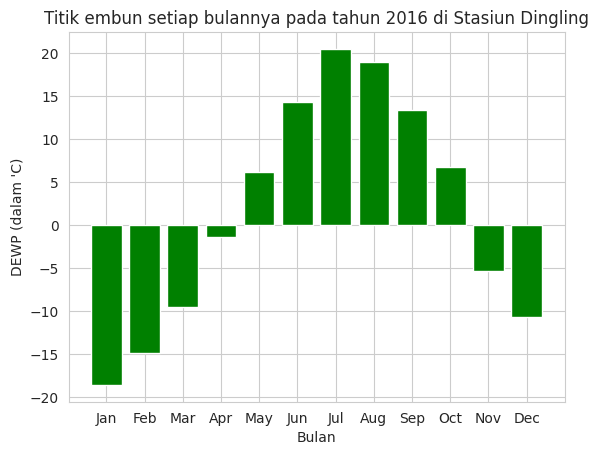

In [37]:
plt.bar(height=wind["DEWP"], x=months, color='green')
plt.xlabel("Bulan")
plt.ylabel("DEWP (dalam 'C)")
plt.title("Titik embun setiap bulannya pada tahun 2016 di Stasiun Dingling")
plt.show()

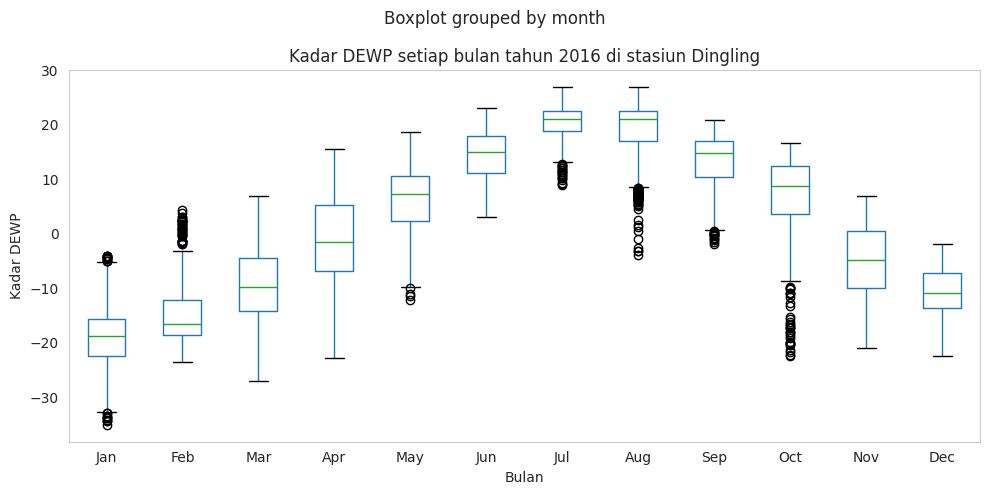

In [38]:
ding_2016_df.boxplot(by="month", column="DEWP", grid=False, figsize=(10,5))
plt.title("Kadar DEWP setiap bulan tahun 2016 di stasiun Dingling")
plt.xlabel("Bulan")
plt.xticks(range(1,13), months)
plt.ylabel("Kadar DEWP")
plt.tight_layout()
plt.show()

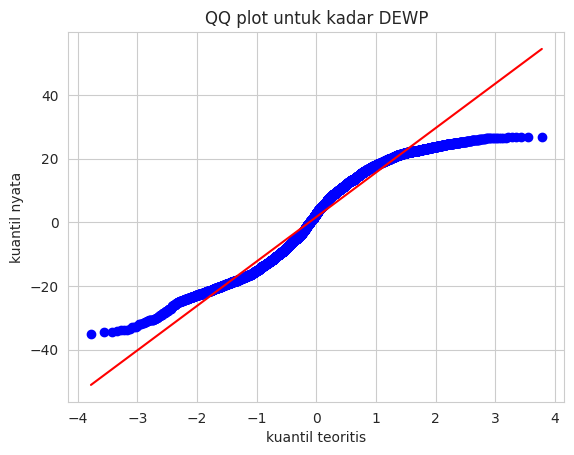

In [39]:
stats.probplot(ding_2016_df['DEWP'], plot=plt)
plt.title("QQ plot untuk kadar DEWP")
plt.xlabel("kuantil teoritis")
plt.ylabel("kuantil nyata")
plt.grid(True)
plt.show()

Insight:
- Bulan Januari-April dan November-Desember memperlihatkan grafik yang berada di bawah nilai 0, dikarenakan saat/berdekatan dengan musim Dingin.
- Terdapat beberapa outlier di bulan Januari, Februari, Mei, Juli-Oktober.
- QQ plot menunjukkan sebaran data tidak normal karena ujung kiri dan kanan keluar dari garis linier.

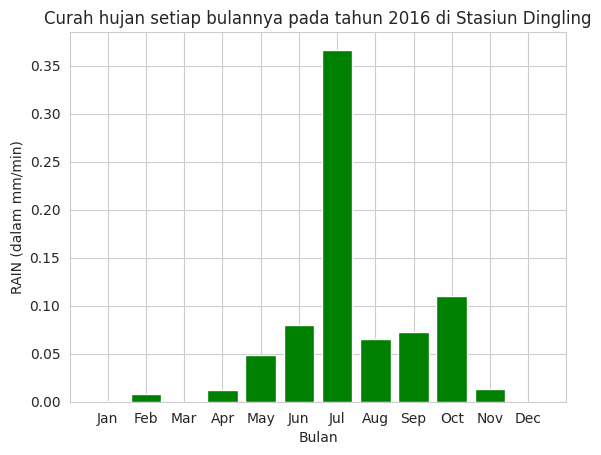

In [40]:
plt.bar(height=wind["RAIN"], x=months, color='green')
plt.xlabel("Bulan")
plt.ylabel("RAIN (dalam mm/min)")
plt.title("Curah hujan setiap bulannya pada tahun 2016 di Stasiun Dingling")
plt.show()

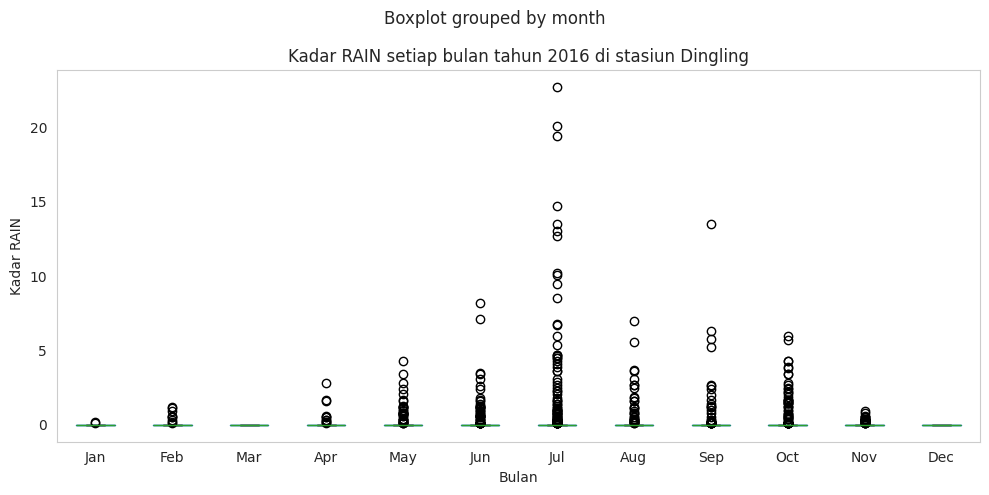

In [41]:
ding_2016_df.boxplot(by="month", column="RAIN", grid=False, figsize=(10,5))
plt.title("Kadar RAIN setiap bulan tahun 2016 di stasiun Dingling")
plt.xlabel("Bulan")
plt.xticks(range(1,13), months)
plt.ylabel("Kadar RAIN")
plt.tight_layout()
plt.show()

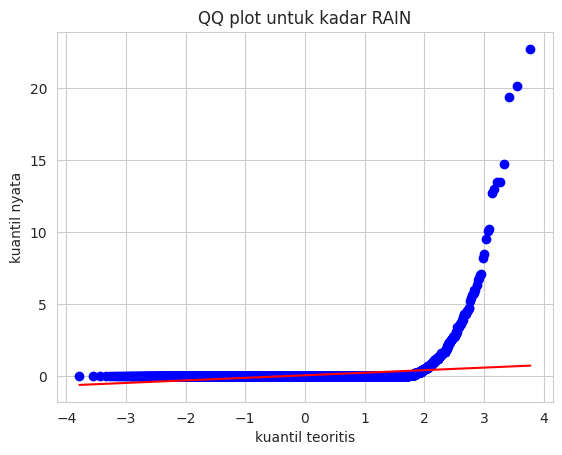

In [42]:
stats.probplot(ding_2016_df['RAIN'], plot=plt)
plt.title("QQ plot untuk kadar RAIN")
plt.xlabel("kuantil teoritis")
plt.ylabel("kuantil nyata")
plt.grid(True)
plt.show()

Insight:
- Bulan Juli memperlihatkan grafik yang sangat tinggi dibandingkan bulan-bulan lainnya.
- Hampir semua bulan menunjukkan outlier terutama di bulan Juli.
- QQ plot menunjukkan sebaran data sangat tidak normal karena garis tidak linier dalam 45 derajat, dan ujung kanan terdapat skewness/berbagai data yang menyimpang dari kuantil teoritis.

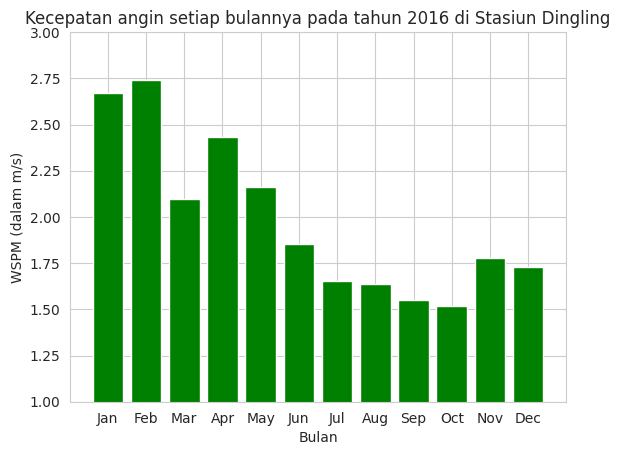

In [43]:
plt.bar(height=wind["WSPM"], x=months, color='green')
plt.xlabel("Bulan")
plt.ylabel("WSPM (dalam m/s)")
plt.ylim(1.0,3.0)
plt.title("Kecepatan angin setiap bulannya pada tahun 2016 di Stasiun Dingling")
plt.show()

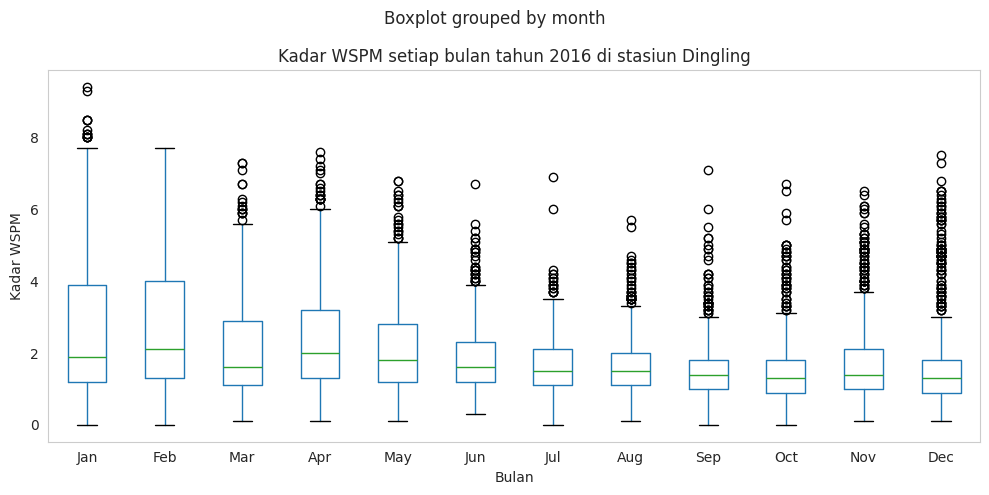

In [44]:
ding_2016_df.boxplot(by="month", column="WSPM", grid=False, figsize=(10,5))
plt.title("Kadar WSPM setiap bulan tahun 2016 di stasiun Dingling")
plt.xlabel("Bulan")
plt.xticks(range(1,13), months)
plt.ylabel("Kadar WSPM")
plt.tight_layout()
plt.show()

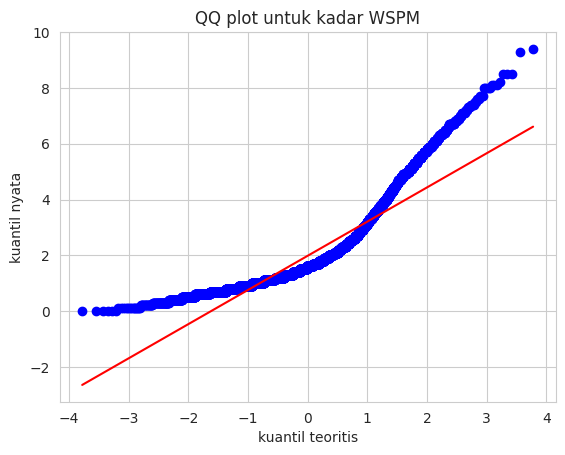

In [45]:
stats.probplot(ding_2016_df['WSPM'], plot=plt)
plt.title("QQ plot untuk kadar WSPM")
plt.xlabel("kuantil teoritis")
plt.ylabel("kuantil nyata")
plt.grid(True)
plt.show()

Insight:
- Bulan Juli-Oktober memperlihatkan grafik yang lebih rendah dibandingkan bulan-bulan lainnya.
- Hampir semua bulan menunjukkan outlier terutama di bulan kecuali Februari.
- QQ plot menunjukkan sebaran data sangat tidak normal karena grafik ini sangat skewed/menyimpang dari garis linier di tengah.

**Insight:**
- Rata-rata kadar PM2.5 dan PM10 pada tahun 2016 di stasiun Dingling adalah 62.93 dan 80.55.
- Rata-rata TEMP dan PRES pada tahun 2016 di stasiun Dingling adalah 13.47 dan 1007.93.
- Rata-rata DEWP, RAIN dan WSPM pada tahun 2016 di stasiun Dingling adalah 1.60, 0.06, dan 1.98.

### EDA Univariate Kategorikal

Penjelasan tahapan:
- Dilakukan grouping/merging menjadi variabel winddir dari database untuk parameter WD yang merupakan data kategorik, lalu dihitung modusnya setiap bulan, dan mengambil tahun 2016 dan dipisahkan setiap bulannya.

/tmp/ipykernel_1652/1806226883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ding_2016_df["arah"] = ding_2016_df['wd']


Text(0.5, 1.0, 'Distribusi arah mata angin pada tahun 2016 di stasiun Dingling')

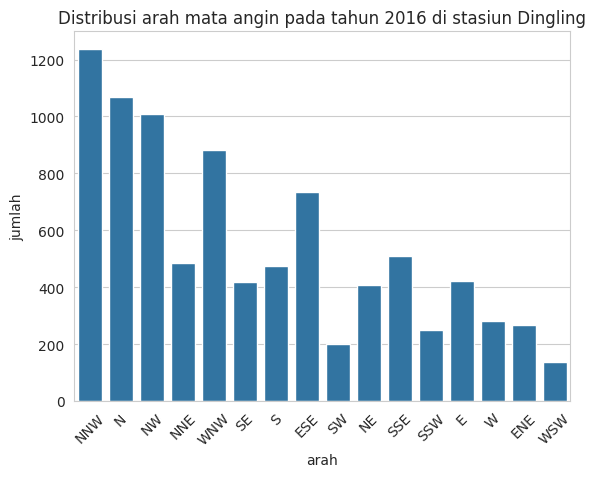

In [46]:
ding_2016_df["arah"] = ding_2016_df['wd']
sns.countplot(x="arah", data = ding_2016_df)
plt.xticks(rotation=45)
plt.ylabel('jumlah')
plt.title('Distribusi arah mata angin pada tahun 2016 di stasiun Dingling')

In [47]:
winddir = ding_df.groupby(by = ['year', 'month']).agg(
    arah = ("wd", lambda x: x.mode()[0])
).sort_values(by= ['year', 'month'], ascending = True).reset_index()
winddir = winddir[(winddir.year == 2016)]
winddir

,year,month,arah
34,2016,1,WNW
35,2016,2,WNW
36,2016,3,NNW
37,2016,4,ESE
38,2016,5,NNW
39,2016,6,N
40,2016,7,ESE
41,2016,8,N
42,2016,9,NW
43,2016,10,NW


Penjelasan tahapan:
- Dilakukan perhitungan frekuensi arah mata angin tersering setiap bulannya lalu diurutkan dari yang tertinggi ke terendah.
- Dipisahkan frekuensi arah mata angin menjadi variabel winddir_freq.

In [48]:
winddir["wind_direction"] = winddir["arah"]
winddir_freq = winddir[['wind_direction', 'arah']].copy()
winddir_freq = winddir_freq.groupby(by="wind_direction").agg({"arah": "count"}).sort_values(by="arah", ascending=False).reset_index()
winddir_freq = winddir_freq.rename(columns = {"arah" : "jumlah"})
winddir_freq

,wind_direction,jumlah
0,NNW,4
1,ESE,2
2,N,2
3,NW,2
4,WNW,2


Penjelasan tahapan:
- Dilakukan pengambilan data dari dataframe sebelumnya, lalu difilter dengan hanya bulan, kadar PM2.5, dan arah angin yang jadi parameter.
- Diambil data tersebut lalu dibuat violin plot untuk melihat sebaran grafiknya secara kasar, beserta arah mata angin mana yang terbanyak pada tahun 2016.
- Dilakukan analisis hubungan antara PM2.5 dengan arah angin.

In [49]:
winddir_pm25 = ding_2016_df[['month', 'PM2.5', 'wd']].copy()
winddir_pm25.head()

,month,PM2.5,wd
24864,1,90.0,NNW
24865,1,82.0,N
24866,1,89.0,N
24867,1,84.0,NNW
24868,1,89.0,NW


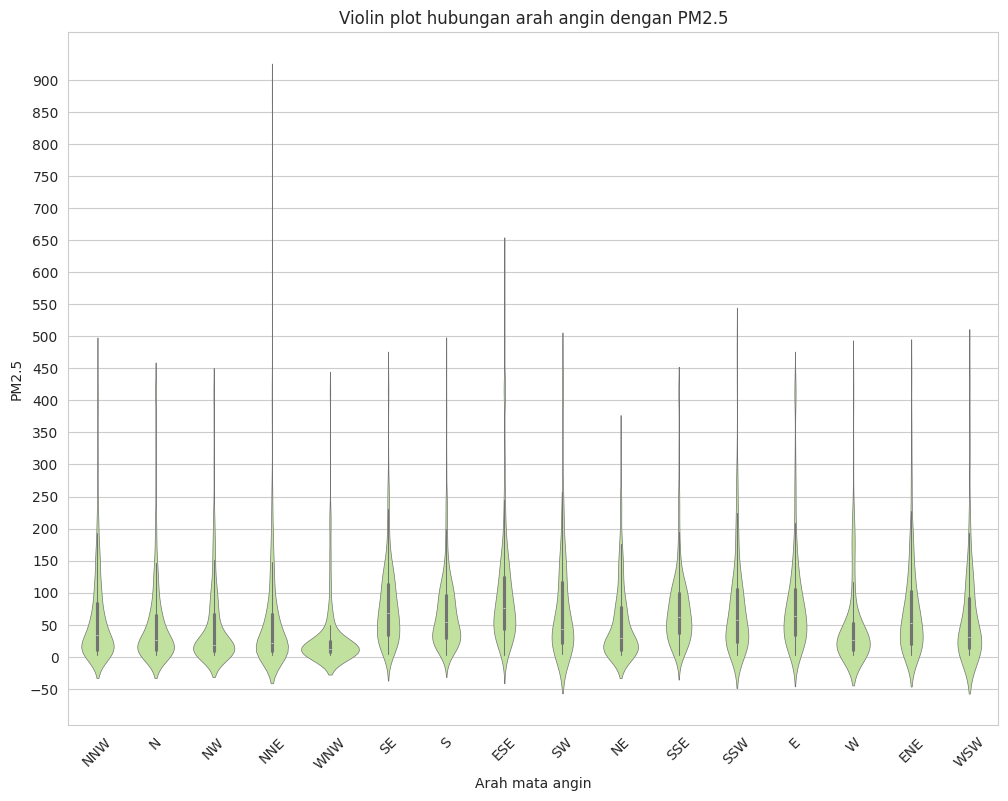

In [50]:
plt.figure(figsize=(12, 9))
sns.violinplot(x='wd', y='PM2.5', data = winddir_pm25, width=1, color='#c0ed93', linewidth=0.5)
plt.xticks(rotation=45)
plt.xlabel('Arah mata angin')
ymin, ymax = winddir_pm25['PM2.5'].min(), winddir_pm25['PM2.5'].max()
plt.yticks(np.arange(-50, ymax+50, 50))
plt.title('Violin plot hubungan arah angin dengan PM2.5')
plt.show()

Penjelasan tahapan:
- Dilakukan pengambilan data dari dataframe sebelumnya, lalu difilter dengan hanya bulan, kadar PM10, dan arah angin yang jadi parameter.
- Diambil data tersebut lalu dibuat violin plot untuk melihat sebaran grafiknya secara kasar, beserta arah mata angin mana yang terbanyak pada tahun 2016.
- Dilakukan analisis hubungan antara PM10 dengan arah angin.

In [51]:
winddir_pm10 = ding_2016_df[['month', 'PM10', 'wd']].copy()
winddir_pm10.head()

,month,PM10,wd
24864,1,90.0,NNW
24865,1,82.0,N
24866,1,89.0,N
24867,1,84.0,NNW
24868,1,89.0,NW


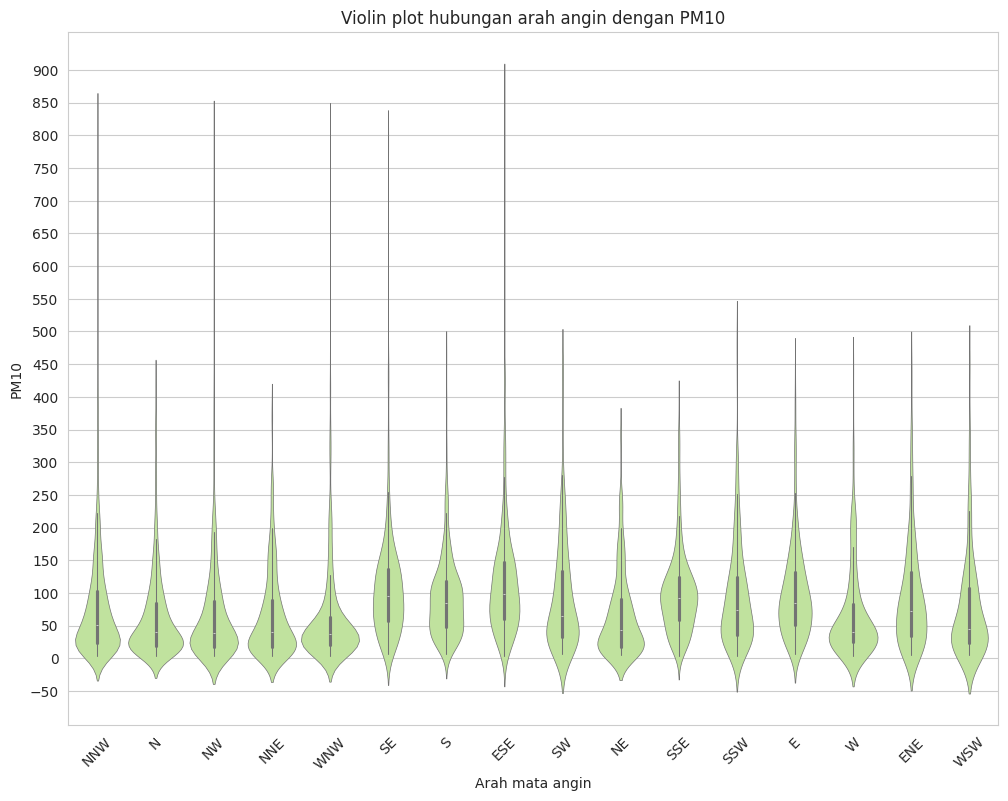

In [52]:
plt.figure(figsize=(12, 9))
sns.violinplot(x='wd', y='PM10', data = winddir_pm10, width=1, color='#c0ed93', linewidth=0.5)
plt.xticks(rotation=45)
plt.xlabel('Arah mata angin')
ymin, ymax = winddir_pm10['PM10'].min(), winddir_pm10['PM10'].max()
plt.yticks(np.arange(-50, ymax+50, 50))
plt.title('Violin plot hubungan arah angin dengan PM10')
plt.show()

**Insight:**
- Arah mata angin NNW menjadi yang paling banyak di tahun 2016 dibandingkan setiap bulannya.
- Arah mata angin WNW memiliki lebar di median yang luas dibandingkan arah mata angin lainnya terhadap kadar PM2.5, menunjukkan WNW punya jumlah yang paling banyak kuantitasnya dibandingkan arah mata angin lainnya, yaitu di kisaran 0-50.
- PM10 juga serupa dengan PM2.5, punya kuantitasnya yang lebih luas pada mata angin WNW, dibandingkan mata angin lainnya.
- PM2.5 punya sebaran yang lebih lebar di mata angin NNE, sementara PM10 memiliki sebaran yang lebar di mata angin ESE.

### EDA Multivariate



*   Correlation Matrix Heatmap terdapat di [Analisis Lanjutan](#scrollTo=iWhnzsJGYUCO)
*   Scatter Plot dan regression line terdapat di [Analisis Lanjutan](#scrollTo=hnYcbKpgdnDx)
* Pair plot beserta analisis statistiknya terdapat di [Pertanyaan 6](#scrollTo=DDwO_Zu5wet4)


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren kadar PM2.5 pada tahun 2016 di Stasiun Dingling?



Penjelasan tahapan:
- Dibuat diagram garis kadar PM2.5 tahun 2016 setiap bulannya.

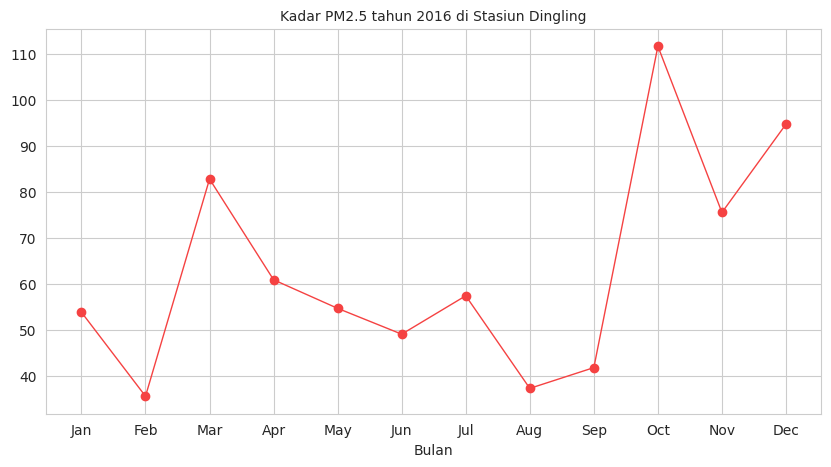

In [53]:
plt.figure(figsize=(10,5))
plt.plot(
    air_pol["month"],
    air_pol["PM2.5"],
    marker = "o",
    linewidth = 1,
    color = "#f54242"
)
plt.title("Kadar PM2.5 tahun 2016 di Stasiun Dingling", loc="center", fontsize=10)
plt.xticks(fontsize=10)
plt.xticks(range(1,13), months)
plt.yticks(fontsize=10)
plt.xlabel("Bulan", fontsize=10)
plt.show()

**Insight:**
- Kadar PM2.5 tertinggi terdapat di bulan Oktober, sementara terendah di bulan Februari.


### Pertanyaan 2: Bagaimana tren kadar PM10 pada tahun 2016 di Stasiun Dingling?

Penjelasan tahapan:
- Dibuat diagram garis kadar PM10 tahun 2016 setiap bulannya.

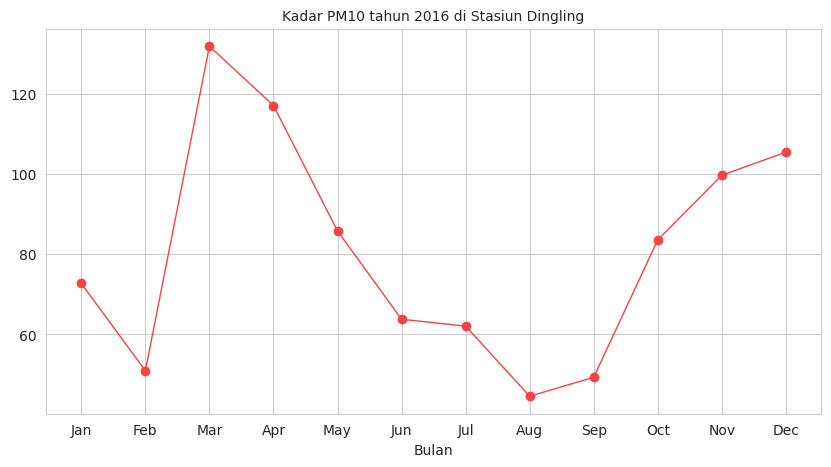

In [54]:
plt.figure(figsize=(10,5))
plt.plot(
    air_pol["month"],
    air_pol["PM10"],
    marker="o",
    linewidth=1,
    color="#f54242"
)
plt.title("Kadar PM10 tahun 2016 di Stasiun Dingling", loc="center", fontsize=10)
plt.xticks(fontsize=10)
plt.xticks(range(1,13), months)
plt.yticks(fontsize=10)
plt.xlabel("Bulan", fontsize=10)
plt.show()

**Insight:**
- Kadar PM10 tertinggi terdapat di bulan Maret, sementara terendah di bulan Februari.


### Pertanyaan 3: Bagaimana tren kualitas udara mencakup suhu dan tekanan angin pada tahun 2016 di Stasiun Dingling?

Penjelasan tahapan:
- Dibuat dua diagram garis parameter TEMP dan PRES tahun 2016 setiap bulannya dengan objek ax dan dua kolom.

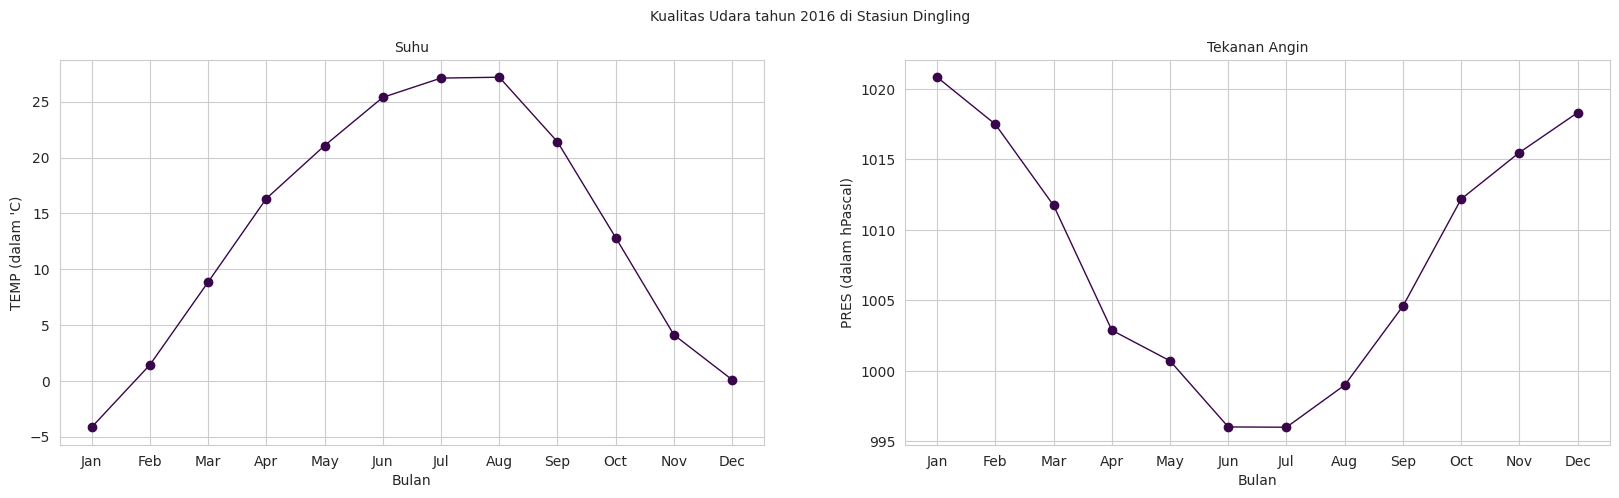

In [55]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20,5))

ax[0].plot(
    air_par["month"],
    air_par["TEMP"],
    marker="o",
    linewidth=1,
    color="#39064B"
    )
ax[0].tick_params(axis="x", labelsize=10)
ax[0].tick_params(axis="y", labelsize=10)
ax[0].set_xlabel("Bulan", fontsize=10)
ax[0].set_xticks(range(1,13), months)
ax[0].set_ylabel("TEMP (dalam 'C)", fontsize=10)
ax[0].set_title("Suhu", fontsize=10)

ax[1].plot(
    air_par["month"],
    air_par["PRES"],
    marker="o",
    linewidth=1,
    color="#39064B"
    )
ax[1].tick_params(axis="x", labelsize=10)
ax[1].tick_params(axis="y", labelsize=10)
ax[1].set_xlabel("Bulan", fontsize=10)
ax[1].set_xticks(range(1,13), months)
ax[1].set_ylabel("PRES (dalam hPascal)", fontsize=10)
ax[1].set_title("Tekanan Angin", fontsize=10)

plt.suptitle("Kualitas Udara tahun 2016 di Stasiun Dingling", fontsize=10)
plt.show()

**Insight:**
- Suhu tertinggi dicapai pada bulan Juli-Agustus, sekitar di atas 25'C, meningat bulan tersebut adalah musim panas.
- Tekanan angin terendah terdapat di bulan Juni hingga Agustus, berada di bawah 1000 hPa


### Pertanyaan 4: Bagaimana tren kualitas udara mencakup titik embun, curah hujan, dan kecepatan angin pada tahun 2016 di Stasiun Dingling?

Penjelasan tahapan:
- Dibuat tiga diagram garis parameter DEWP, RAIN, dan WSPM tahun 2016 setiap bulannya dengan objek ax dan tiga kolom.

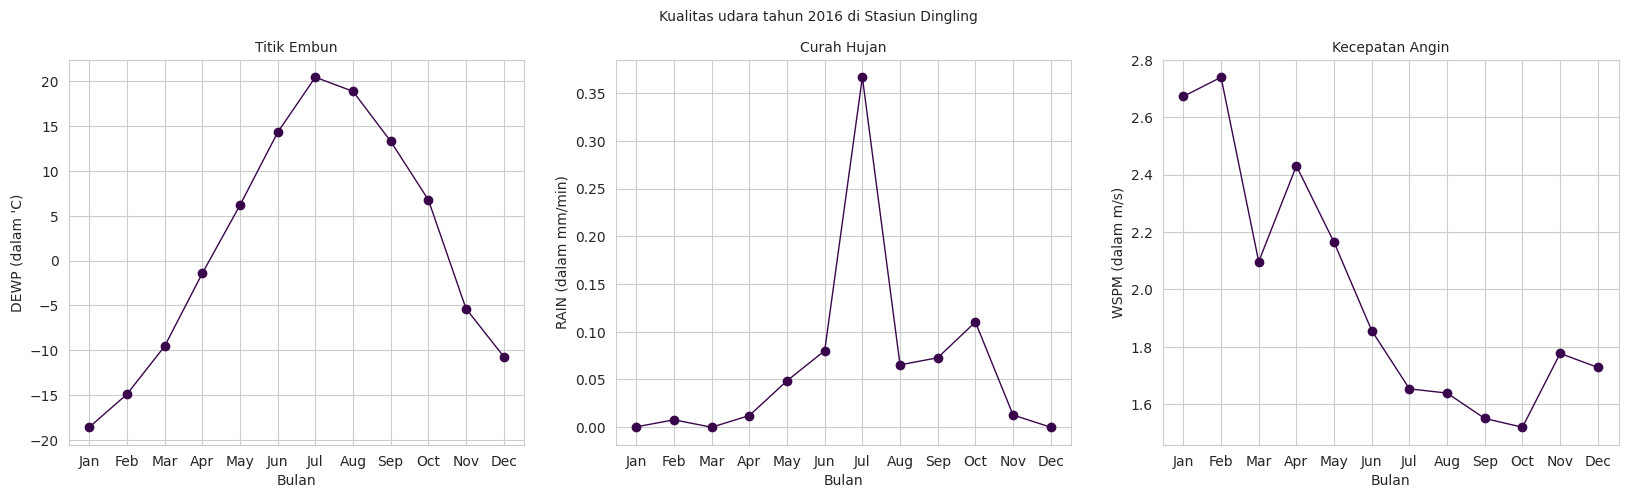

In [56]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,5))

ax[0].plot(
    wind["month"],
    wind["DEWP"],
    marker="o",
    linewidth=1,
    color="#39064B"
    )
ax[0].tick_params(axis="x", labelsize=10)
ax[0].tick_params(axis="y", labelsize=10)
ax[0].set_xlabel("Bulan", fontsize=10)
ax[0].set_xticks(range(1,13), months)
ax[0].set_ylabel("DEWP (dalam 'C)", fontsize=10)
ax[0].set_title("Titik Embun", fontsize=10)

ax[1].plot(
    wind["month"],
    wind["RAIN"],
    marker="o",
    linewidth=1,
    color="#39064B"
    )
ax[1].tick_params(axis="x", labelsize=10)
ax[1].tick_params(axis="y", labelsize=10)
ax[1].set_xlabel("Bulan", fontsize=10)
ax[1].set_xticks(range(1,13), months)
ax[1].set_ylabel("RAIN (dalam mm/min)", fontsize=10)
ax[1].set_title("Curah Hujan", fontsize=10)

ax[2].plot(
    wind["month"],
    wind["WSPM"],
    marker="o",
    linewidth=1,
    color="#39064B"
    )
ax[2].tick_params(axis="x", labelsize=10)
ax[2].tick_params(axis="y", labelsize=10)
ax[2].set_xlabel("Bulan", fontsize=10)
ax[2].set_xticks(range(1,13), months)
ax[2].set_ylabel("WSPM (dalam m/s)", fontsize=10)
ax[2].set_title("Kecepatan Angin", fontsize=10)

plt.suptitle("Kualitas udara tahun 2016 di Stasiun Dingling", fontsize=10)
plt.show()

Insights:
- Titik embun memiliki nilai paling tinggi di bulan Juli yaitu 20'C
- Curah hujan pada tahun 2016 di Stasiun Dingling sempat mencapai puncak yang cukup tinggi dengan nilai lebih dari 0.35 mm/min di bulan Juli.
- Kecepatan angin seiring bulan berganti relatif semakin turun, dengan nilai tertinggi ada di bulan Februari.


### Pertanyaan 5: Bagaimana distribusi arah mata angin pada 2016 di Stasiun Dingling?

Penjelasan tahapan:
- Dibuat histogram frekuensi arah mata angin terbanyak di tahun 2016.

Histogram frekuensi secara umum dapat dilihat di [EDA Univariate Kategorikal](#scrollTo=4BF1l2pPUqLL)

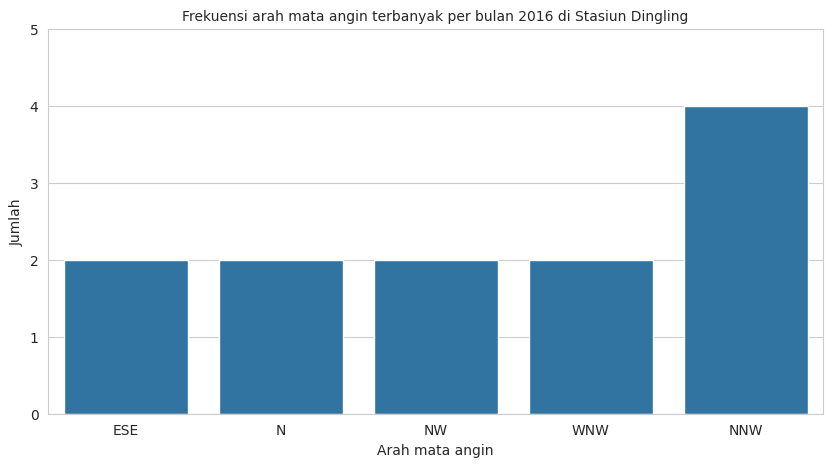

In [57]:
plt.figure(figsize=(10,5))

sns.barplot(
    y="jumlah",
    x="wind_direction",
    data=winddir_freq.sort_values(by="jumlah", ascending=True)
)

plt.title("Frekuensi arah mata angin terbanyak per bulan 2016 di Stasiun Dingling", fontsize=10)
plt.ylabel("Jumlah", fontsize=10)
plt.yticks(range(0,6))
plt.xlabel("Arah mata angin", fontsize=10)
plt.show()


Insights:
- Arah mata angin NNW menjadi yang paling banyak terjadi dibandingkan mata angin lainnya.

### Pertanyaan 6: Bagaimana status kualitas udara pada tahun 2016 di Stasiun Dingling berdasarkan PM2.5 dan PM10 di setiap bulannya?

In [58]:
air_pol_melt = air_pol.melt(
    id_vars = ['month'],
    value_vars = ['PM2.5', 'PM10'],
    var_name = 'polutan',
    value_name = 'nilai'

)
print(air_pol_melt.head())

   month polutan      nilai
0      1   PM2.5  53.833333
1      2   PM2.5  35.554598
2      3   PM2.5  82.810484
3      4   PM2.5  60.886111
4      5   PM2.5  54.673387


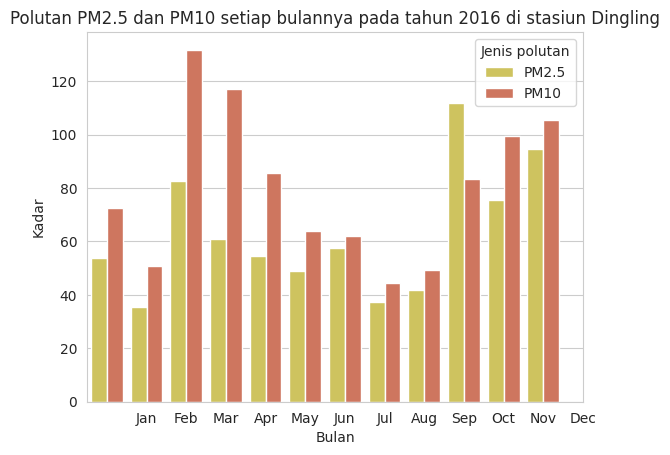

In [59]:
sns.barplot(
    data = air_pol_melt,
    x = 'month',
    y = 'nilai',
    hue = 'polutan',
    palette = {'PM2.5': '#e0d24c', 'PM10': '#e06c4c'}
)
plt.title('Polutan PM2.5 dan PM10 setiap bulannya pada tahun 2016 di stasiun Dingling')
plt.xlabel('Bulan')
plt.xticks(range(1,13), months)
plt.ylabel('Kadar')
plt.legend(title = 'Jenis polutan')
plt.show()

Penjelasan tahapan:
- Dibuat kategorisasi dengan cutoff beberapa poin di arrray bins beserta jenisnya masing-masing untuk parameter PM2.5 dan PM10.
- Dibuat visualisasinya dengan barplot dengan dibedakan warnanya bedasarkan kategori baik untuk PM2.5 dan PM10.

In [60]:
bins = [0, 15.5, 55.4, 150.4, 250.4, 500]
bins2 = [0, 50, 150, 350, 420, 1000]
cat = ["Baik", "Sedang", "Tidak sehat", "Sangat tidak sehat", "Berbahaya"]
air_pol["Kategori PM2.5"] = pd.cut(air_pol["PM2.5"], bins=bins, labels=cat, include_lowest=True)
air_pol["Kategori PM10"] = pd.cut(air_pol["PM10"], bins=bins2, labels=cat, include_lowest=True)
print(air_pol)

    year  month       PM2.5        PM10 Kategori PM2.5 Kategori PM10
34  2016      1   53.833333   72.701613         Sedang        Sedang
35  2016      2   35.554598   50.981322         Sedang        Sedang
36  2016      3   82.810484  131.787634    Tidak sehat        Sedang
37  2016      4   60.886111  117.018056    Tidak sehat        Sedang
38  2016      5   54.673387   85.774194         Sedang        Sedang
39  2016      6   49.056944   63.779167         Sedang        Sedang
40  2016      7   57.411290   62.083333    Tidak sehat        Sedang
41  2016      8   37.262097   44.619624         Sedang          Baik
42  2016      9   41.779167   49.331944         Sedang          Baik
43  2016     10  111.706989   83.571237    Tidak sehat        Sedang
44  2016     11   75.534722   99.651389    Tidak sehat        Sedang
45  2016     12   94.748656  105.403226    Tidak sehat        Sedang


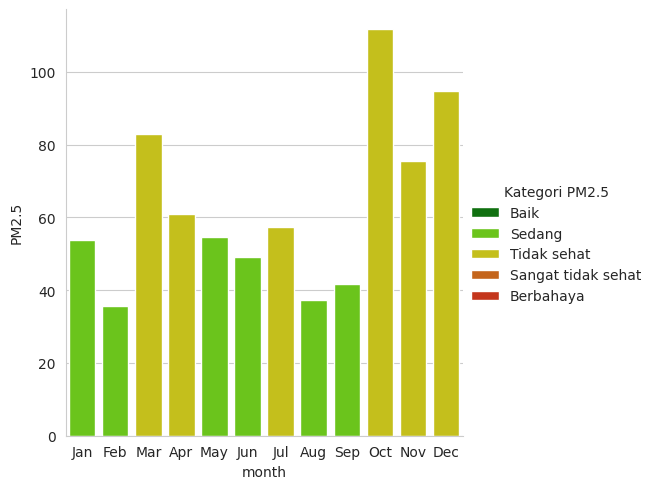

In [61]:
cat_pallete = {
    "Baik": '#008000',
    "Sedang": '#69e000',
    "Tidak sehat": '#e0d900',
    "Sangat tidak sehat": '#e06100',
    "Berbahaya": '#e02200'
    }

sns.catplot(
    x = "month",
    y = "PM2.5",
    hue = "Kategori PM2.5",
    data = air_pol,
    kind = 'bar',
    palette = cat_pallete)
plt.xticks(range(0,12), months)
plt.show()

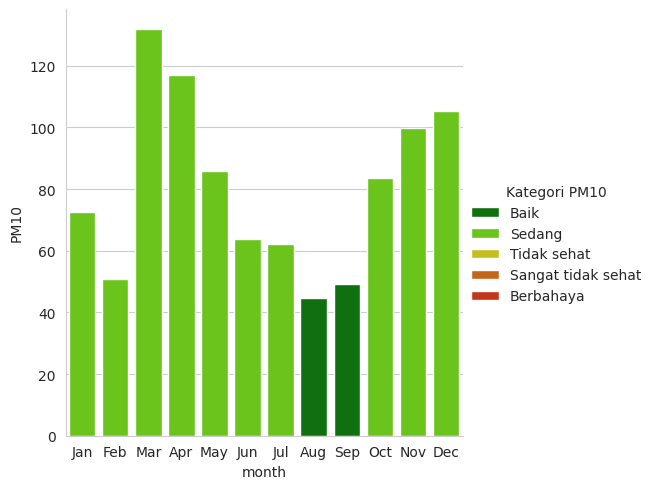

In [62]:
cat_pallete = {
    "Baik": '#008000',
    "Sedang": '#69e000',
    "Tidak sehat": '#e0d900',
    "Sangat tidak sehat": '#e06100',
    "Berbahaya": '#e02200'
    }

sns.catplot(
    x = "month",
    y = "PM10",
    hue = "Kategori PM10",
    data = air_pol,
    kind = 'bar',
    palette = cat_pallete)
plt.xticks(range(0,12), months)
plt.show()

In [63]:
air_pol_crosstab = pd.crosstab(air_pol['Kategori PM2.5'],
            air_pol['Kategori PM10'],
            margins = False)
print(air_pol_crosstab.to_markdown(tablefmt='grid'))
chi2, pval, dof, expected = stats.chi2_contingency(air_pol_crosstab)
print(f"Nilai chi square: {chi2:.5f}")
print(f"Nilai p value: {pval:.4f}")
print(f"Nilai degree of freedom: {dof:.5f}")

+------------------+--------+----------+
| Kategori PM2.5   |   Baik |   Sedang |
+==================+========+==========+
| Sedang           |      2 |        4 |
+------------------+--------+----------+
| Tidak sehat      |      0 |        6 |
+------------------+--------+----------+
Nilai chi square: 0.60000
Nilai p value: 0.4386
Nilai degree of freedom: 1.00000


**Insight:**
- Polutan PM2.5 paling banyak terdapat di bulan Oktober, sementara PM10 terdapat di bulan Maret.
- Kualitas udara pada tahun 2016 di Stasiun Dingling menurut kadar PM2.5 dan PM10 sebagian besar sedang.
- Hubungan antara kategori PM2.5 dengan PM10 tidak bemakna, dikarenakan nilai chi square yang lebih rendah dibandingkan critical value untuk df=1 (0.60 < 3.84)
[sumber](https://media.geeksforgeeks.org/wp-content/uploads/20200604234722/download.png).
- Nilai p value terhitung juga di atas standar (p < 0,05), sehingga gagasan ini memperkuat tidak signifikan hubungan kategori PM2.5 dengan PM10.





## Analisis Lanjutan (Opsional)

### Correlation matrix heatmap

Penjelasan tahapan:
- Dibuat korelasi antara setiap polutan dengan metode korelasi Pearson.

Tujuan analisis:
- Melihat paramater numerik antara dua polutan menggunakan metode koefisien korelasi Pearson.
- Tujuan metode ini adalah menilai linearitas antara dua variabel beserta hubungan perbandingannya dan kekuatannya.
- Nilai positif menandakan hubungan berbanding lurus, sementara nilai negatif menandakan hubungan berbanding terbalik.
- Koefisien korelasi (r) <0,3 menunjukkan korelasi lemah, 0,3-0,6 menunjukkan korelasi sedang, dan >0,6 menunjukkan korelasi kuat.

In [64]:
corr_df = ding_2016_df[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES']].copy()
corr_df = corr_df.corr(method="pearson")
corr_df

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES
PM2.5,1.000000,0.759307,0.443259,0.694555,0.703400,-0.056141,-0.034813,-0.062517
PM10,0.759307,1.000000,0.459277,0.672667,0.645634,-0.042425,-0.043699,-0.087273
SO2,0.443259,0.459277,1.000000,0.633857,0.592876,-0.185509,-0.347998,0.224735
NO2,0.694555,0.672667,0.633857,1.000000,0.816177,-0.229574,-0.273706,0.105308
CO,0.703400,0.645634,0.592876,0.816177,1.000000,-0.201957,-0.263750,0.117594
O3,-0.056141,-0.042425,-0.185509,-0.229574,-0.201957,1.000000,0.480047,-0.378063
TEMP,-0.034813,-0.043699,-0.347998,-0.273706,-0.263750,0.480047,1.000000,-0.848708
PRES,-0.062517,-0.087273,0.224735,0.105308,0.117594,-0.378063,-0.848708,1.000000


Penjelasan tahapan:
- Dibuat heatmap antara setiap polutan berdasarkan korelasi Pearson sebelumnya.

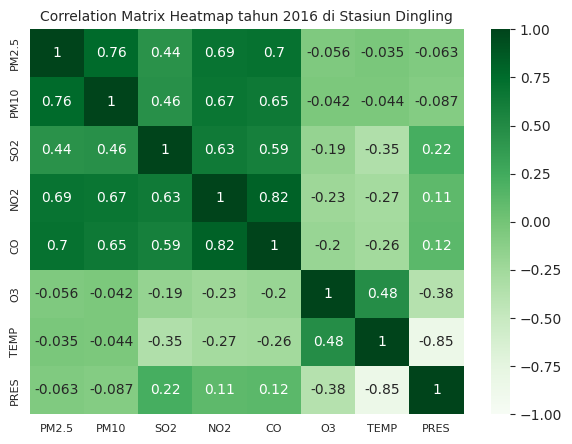

In [65]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_df, vmax = 1, vmin = -1, center = 0, cmap='Greens', annot=True)
ax.tick_params(labelsize = 8)
ax.set_title("Correlation Matrix Heatmap tahun 2016 di Stasiun Dingling", loc="center", fontsize=10)
plt.show()

Insights:
- Hubungan yang kuat ditemukan antar polutan (PM2.5 hingga CO), kecuali 03.
- Hubungan TEMP dengan PRES dijelaskan di bagian [bawah](#scrollTo=ynUL8ABBhv61)

### Scatter plot dan Regression line visualizaiton

Penjelasan tahapan:
- Dibuat scatter plot dan Regression Line Visualization antara polutan PM2.5 vs PM10, kualitas udara TEMP vs PRES, dan TEMP vs DEWP tahun 2016 di stasiun Dingling.

Tujuan analisis:
- Menilai secara visual hubungan parameter antar polutan, secara spesifik PM2.5 dan PM10.
- Menilai secara visual hubungan parameter suhu dengan berbagai kualitas udara, yaitu tekanan angin dan titik embun.

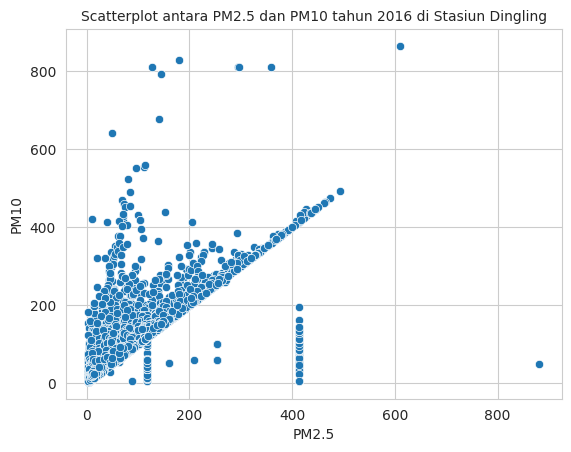

In [66]:
sns.scatterplot(x="PM2.5", y='PM10', data=ding_2016_df)
plt.title("Scatterplot antara PM2.5 dan PM10 tahun 2016 di Stasiun Dingling", fontsize=10)
plt.show()

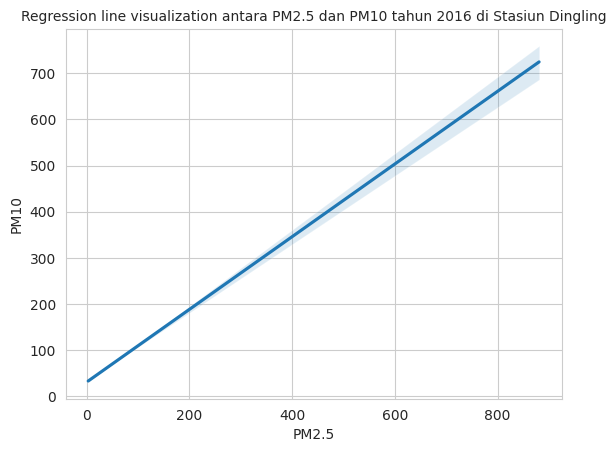

In [67]:
sns.regplot(x="PM2.5", y='PM10', data=ding_2016_df, scatter=False)
plt.title("Regression line visualization antara PM2.5 dan PM10 tahun 2016 di Stasiun Dingling", fontsize=10)
plt.show()

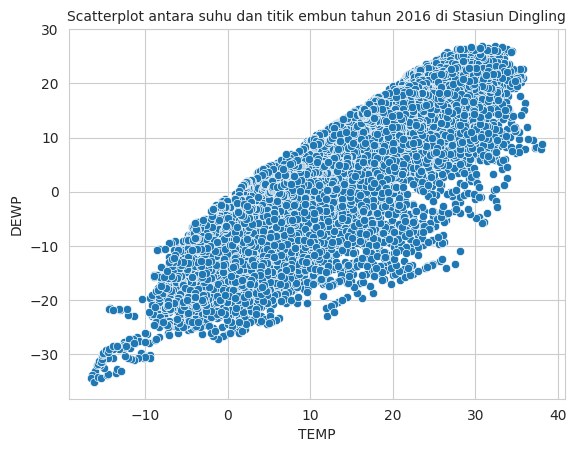

In [68]:
sns.scatterplot(x="TEMP", y='DEWP', data=ding_2016_df)
plt.title("Scatterplot antara suhu dan titik embun tahun 2016 di Stasiun Dingling", fontsize=10)
plt.show()

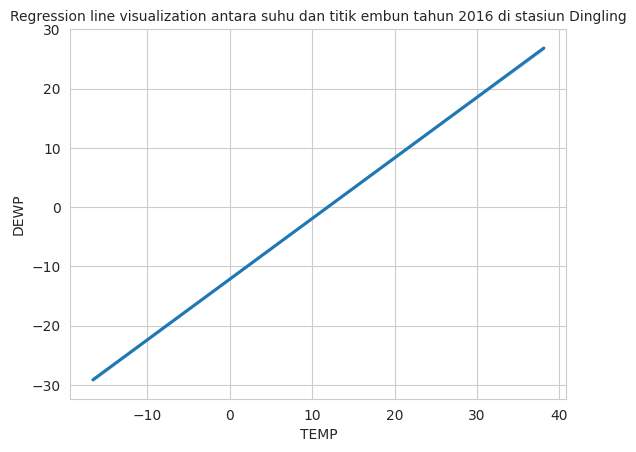

In [69]:
sns.regplot(x='TEMP', y='DEWP', data=ding_2016_df, scatter=False, ci=95)
plt.title("Regression line visualization antara suhu dan titik embun tahun 2016 di stasiun Dingling", fontsize=10)
plt.show()

### Pertanyaan 7: Bagaimana hubungan antara suhu dengan tekanan angin pada tahun 2016 di Stasiun Dingling?

In [70]:
corr_df = ding_2016_df[['TEMP', 'PRES']].copy()
corr_df = corr_df.corr(method="pearson")
corr_df

,TEMP,PRES
TEMP,1.000000,-0.848708
PRES,-0.848708,1.000000


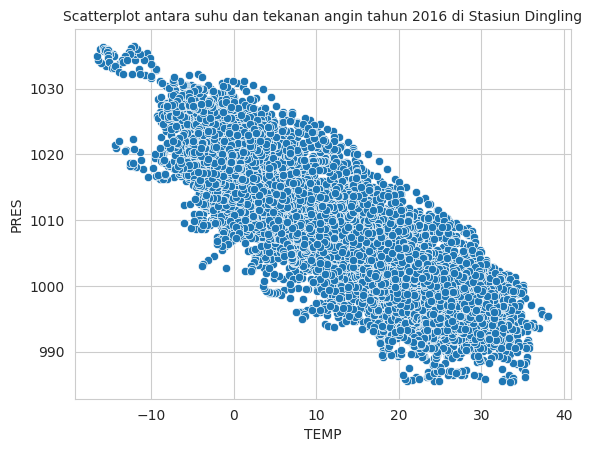

In [71]:
sns.scatterplot(x="TEMP", y='PRES', data=ding_2016_df)
plt.title("Scatterplot antara suhu dan tekanan angin tahun 2016 di Stasiun Dingling", fontsize=10)
plt.show()

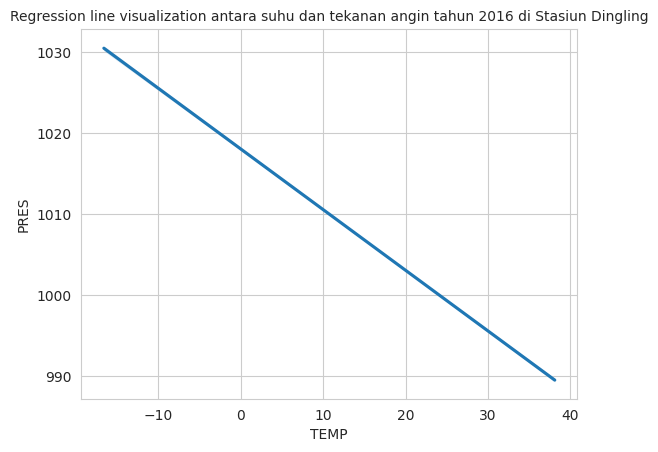

In [72]:
sns.regplot(x="TEMP", y='PRES', data=ding_2016_df, scatter=False, ci=95)
plt.title("Regression line visualization antara suhu dan tekanan angin tahun 2016 di Stasiun Dingling", fontsize=10)
plt.show()

Insights:
- Hubungan antara suhu dan tekanan angin berbanding terbalik dikarenakan nilai korelasi negatif dan kuat (>0,7).
- Scatterplot dan Grafik garis linier menunjukkan down-trend.


## Conclusion

- Tren kadar PM2.5 pada tahun 2016 di Stasiun Dingling mengalami fluktuasi, dengan penurunan terlama mulai di bulan Maret sampai September, dengan nilai tertinggi terdapat di bulan Oktober, sementara terendah di bulan Februari.
- Tren kadar PM10 pada tahun 2016 di Stasiun Dingling penurunan terlama mulai di bulan Maret sampai September, dengan nilai tertinggi terdapat di bulan Maret, sementara terendah di bulan Februari.
- Tren suhu pada tahun 2016 di Stasiun Dingling mengalami peningkatan hingga di bulan Juli-Agustus, kemudian turun hingga akhir tahun.
- Berkebalikan dengan suhu, tren tekanan angin pada tahun 2016 di Stasiun Dingling mengalami penurunan hingga di bulan Juni-Juli, kemudian naik hingga akhir tahun.
- Tren titik embun pada tahun 2016 di Stasiun Dingling meningkat paling tinggi di bulan Juli, kemudian dilanjutkan dengan penurunan hingga akhir tahun.
- Tren curah hujan pada tahun 2016 di Stasiun Dingling berfluktuasi, namun tetap sebagian besar berada di bawah 0,10 mm/min, kecuali di bulan Juli dan Oktober yang dimungkinkan akibat adanya outlier.
- Tren kecepatan angin pada tahun 2016 di Stasiun Dingling sebagian besar turun setiap bulannya, kecuali sempat mengalami peningkatan sedikit di bulan Februari dan April.
- Arah mata angin terbanyak pada tahun 2016 di Stasiun Dingling paling banyak mengarah ke NNW atau ke utara-barat laut.
- Status kualitas udara pada tahun 2016 di Stasiun Dingling menurut kadar PM2.5 sebagian besar menunjukkan kategori tidak sehat, sementara menurut kadar PM10 sebagian besar menunjukkan kategori sedang. Bulan Agustus dan September di kedua jenis kadar menunjukkan level polutan yang rendah dibandingkan bulan-bulan lainnya, sehingga PM2.5 dikategorikan sedang, sementara PM10 dikategorikan baik.
- Hubungan antara suhu dengan tekanan angin di tahun 2016 di stasiun Dingling yaitu berkorelasi negatif dan di atas 0,70. Artinya semakin tinggi suhu, semakin rendah tekanan anginnya, dan juga korelasi di bawah 0,70 menurut metode Pearson adalah korelasi kuat, artinya korelasi berbanding terbalik ini cukup signifikan saling berpengaruh.
- Rekomendasi Action item: Perlu dilakukan investigasi ulang terhadap data-data outlier terutama di kadar [PM2.5](#scrollTo=kIDdAVBNoekk), [PM10](#scrollTo=lGPZoZkvTHfa), dan [Curah Hujan](#scrollTo=YnbdBGZRUxJS). Ketiga parameter ini perlu diperhatikan apakah benar sudah sesuai dengan hasil pengukuran, apakah ada kesalahan input seperti typo/double filling/missing. Metode ffill menjadi alternatif untuk mengisi data yang sebelumnya [null](#scrollTo=xuy-c_lnNArf), akan tetapi tetap rechecking manual satu persatu sangat dibutuhkan agar hasil visualisasi plot lebih objektif.

In [73]:
ding_2016_df.to_csv("ding_2016.csv", index=False)